# 🤖 Agente Asistente Tributario Autónomo — Notebook de Experimentos

**Proyecto:** Máster en Ingeniería del Software e IA — Módulo CESA7002  
**Autor:** Juan Ml. Salcedo Martínez  
**Repositorio:** https://github.com/jmsalcedo/ia_final_agente-tributario-rdes  
**Demo en vivo:** https://jmsmartinez-ia-final-agente-tributario-rdes.hf.space/

---

## 🎯 ¿Qué construyo en este notebook?

En este cuaderno construyo, paso a paso, mi **sistema multiagente** que responde preguntas tributarias complejas para España (IRPF) y República Dominicana (ISR/RST). El sistema combina:

- **Tres agentes especializados:** un Planificador que descompone la pregunta, un Recuperador que busca en la base documental, y un Redactor que sintetiza la respuesta final.
- **RAG (Retrieval-Augmented Generation):** indexo la normativa oficial de la AEAT y la DGII con embeddings multilingües, y recupero los fragmentos relevantes para cada pregunta.
- **Política bandit ε-greedy:** un mecanismo de aprendizaje por refuerzo ligero que aprende qué estrategia de redacción funciona mejor.
- **LLM Llama 3.1 8B Instant** servido vía Groq (gratuito, sin tarjeta).
- **Despliegue en producción** en Hugging Face Spaces (Docker SDK, 16 GB de RAM).
- **Métricas cuantitativas:** mido la relevancia, cobertura y fundamentación de las respuestas.

> 💡 He diseñado este notebook para ejecutarlo de arriba hacia abajo. En cada celda explico qué hago y por qué tomo esa decisión.

> 🌐 **Acceso público al demo:** https://jmsmartinez-ia-final-agente-tributario-rdes.hf.space/

## 1️⃣ Instalación de dependencias

Si ejecuto el notebook por primera vez, descomento la línea siguiente para instalar las dependencias. Si ya he hecho `pip install -r requirements.txt` antes, me salto este paso.

In [ ]:
# !pip install -q -r ../requirements.txt

: 

## 2️⃣ Configuración y variables de entorno

Cargo las variables de entorno desde el archivo `.env` (que contiene mi clave de Groq). Si no la tengo configurada, mi sistema funcionará en **modo demo** con respuestas plantilla — útil para probar la lógica sin gastar cuota.

**¿Cómo obtengo la clave de Groq?** Creo una cuenta gratuita en https://console.groq.com (con Google o GitHub, sin tarjeta), voy a **API Keys → Create API Key**, copio la clave que empieza por `gsk_` y la pego en mi `.env` como `GROQ_API_KEY=gsk_...`. Groq me ofrece **Llama 3.1 8B Instant** a ~300 tokens/segundo con 14.400 requests/día gratis.

Alternativamente, mi sistema soporta HuggingFace como fallback si configuro `HF_API_TOKEN`.

In [1]:
# Añado la raíz del proyecto al path de Python para poder importar el paquete `app`
import sys, os
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent  # subo un nivel desde /notebook a la raíz
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# Cargo el .env desde la raíz del proyecto
from dotenv import load_dotenv
load_dotenv(PROJECT_ROOT / ".env")

# Detecto el proveedor activo
groq_token = os.getenv("GROQ_API_KEY", "")
hf_token = os.getenv("HF_API_TOKEN", "")

if groq_token.startswith("gsk_"):
    mode = "GROQ ✅"
    model = os.getenv("GROQ_MODEL_ID", "llama-3.1-8b-instant")
elif hf_token.startswith("hf_") and "tu_token" not in hf_token:
    mode = "HUGGINGFACE ✅"
    model = os.getenv("HF_MODEL_ID", "mistralai/Mistral-7B-Instruct-v0.3")
else:
    mode = "DEMO ⚠️"
    model = "(sin token configurado)"

print(f"Modo activo: {mode}")
print(f"Modelo configurado: {model}")

Modo activo: GROQ ✅
Modelo configurado: llama-3.1-8b-instant


## 3️⃣ Descarga y procesado del corpus

Mi agente necesita una **base documental** sobre la que razonar. He elegido dos fuentes:

- 🇪🇸 **AEAT** (Agencia Tributaria): manuales prácticos del IRPF 2024 (autónomos y deducciones autonómicas).
- 🇩🇴 **DGII** (Dirección General de Impuestos Internos): Código Tributario y normativa del RST.

Para que el notebook sea reproducible sin esperar descargas, incluyo **muestras pre-procesadas** en `data/sample/` que ya contienen la información esencial. Si quiero trabajar con los PDFs completos, ejecuto `python scripts/download_corpus.py` desde la raíz del proyecto.

In [2]:
# Listo los documentos de muestra que vienen pre-procesados
sample_dir = PROJECT_ROOT / "data" / "sample"
for f in sorted(sample_dir.glob("*.txt")):
    print(f"📄 {f.name:45s} ({f.stat().st_size // 1024} KB)")

📄 DO_cumplimiento_fiscal.txt                    (5 KB)
📄 DO_profesional_ISR_RST.txt                    (7 KB)
📄 ES_autonomos_IRPF_2024.txt                    (6 KB)
📄 ES_deducciones_autonomicas.txt                (4 KB)


## 4️⃣ Construcción del índice vectorial con ChromaDB

Aquí desarrollo la lógica del **RAG**:

1. **Tokenización en chunks:** divido cada documento en trozos de ~600 tokens con solapamiento, porque los LLMs tienen ventana de contexto limitada y quiero preservar contexto entre cortes.
2. **Embeddings multilingües:** cada chunk lo convierto en un vector de 384 dimensiones usando `paraphrase-multilingual-MiniLM-L12-v2`. He elegido este modelo porque (a) soporta español, (b) es ligero (~120 MB), (c) tiene buena calidad para búsqueda semántica.
3. **Almacenamiento en ChromaDB:** uso una base vectorial local que persiste en disco. No requiere servidor externo, lo que la hace perfecta para Hugging Face Spaces y para portabilidad.
4. **Metadatos:** a cada chunk le añado su `pais` (ES/DO), `source` y `page` para poder filtrar después.

> 📚 Referencia teórica: Lewis et al. (2020), *Retrieval-Augmented Generation for Knowledge-Intensive NLP Tasks* (NeurIPS).

In [3]:
# Importo el pipeline RAG e indexo las muestras
from app.core.rag import RAGPipeline
from app.core.ingest import ingest_directory

# Inicializo el pipeline (descarga el modelo de embeddings la primera vez, ~120MB)
rag = RAGPipeline()

# Indexo las muestras
total_chunks = ingest_directory(PROJECT_ROOT / "data" / "sample", rag)
print(f"\n✅ {total_chunks} chunks indexados")
print(f"📊 Total en ChromaDB: {rag.count()} documentos")

c:\ia_final_agente-tributario-rdes\venv\Lib\site-packages\sentence_transformers\cross_encoder\CrossEncoder.py:11: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm, trange


18:55:55 | INFO    | app.core.rag | Cargando modelo de embeddings: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2


Failed to send telemetry event ClientStartEvent: capture() takes 1 positional argument but 3 were given
Failed to send telemetry event ClientCreateCollectionEvent: capture() takes 1 positional argument but 3 were given


18:55:59 | INFO    | app.core.rag | ChromaDB lista. Documentos en colección: 0
18:55:59 | INFO    | app.core.ingest | Indexando DO_cumplimiento_fiscal.txt (país=ES)...


Failed to send telemetry event CollectionAddEvent: capture() takes 1 positional argument but 3 were given


18:55:59 | INFO    | app.core.ingest |   → 3 chunks
18:55:59 | INFO    | app.core.ingest | Indexando DO_profesional_ISR_RST.txt (país=DO)...
18:55:59 | INFO    | app.core.ingest |   → 4 chunks
18:55:59 | INFO    | app.core.ingest | Indexando ES_autonomos_IRPF_2024.txt (país=ES)...
18:55:59 | INFO    | app.core.ingest |   → 3 chunks
18:55:59 | INFO    | app.core.ingest | Indexando ES_deducciones_autonomicas.txt (país=ES)...
18:55:59 | INFO    | app.core.ingest |   → 2 chunks

✅ 12 chunks indexados
📊 Total en ChromaDB: 12 documentos


Ahora pruebo la búsqueda semántica con una consulta de ejemplo, filtrando por país:

In [4]:
# Búsqueda semántica filtrada por España
resultados = rag.retrieve("gastos deducibles para un autónomo en estimación directa", pais="ES", top_k=3)

for i, chunk in enumerate(resultados, 1):
    print(f"\n--- Resultado {i} ({chunk.source}, p.{chunk.page}) ---")
    print(chunk.text[:300] + "...")

Failed to send telemetry event CollectionQueryEvent: capture() takes 1 positional argument but 3 were given



--- Resultado 1 (DO_cumplimiento_fiscal.txt, p.1) ---
antes del 31 de marzo. Para una persona física en RST de Ingresos: - Anual: Declaración Jurada simplificada — antes del 28 de febrero. - Trimestral: Cuatro cuotas anticipadas del impuesto estimado. - No requiere declaración mensual de ITBIS. ==========================================================...

--- Resultado 2 (ES_deducciones_autonomicas.txt, p.1) ---
DEDUCCIONES AUTONÓMICAS RELEVANTES EN EL IRPF ESPAÑOL — RESUMEN OPERATIVO Fuente: Manual Práctico Renta 2024 Tomo 2 (AEAT). Documento sintético. ========================================================================== 1. NATURALEZA DE LAS DEDUCCIONES AUTONÓMICAS ===================================...

--- Resultado 3 (ES_deducciones_autonomicas.txt, p.1) ---
900 €). - Deducción por arrendamiento de vivienda habitual para menores de 35 años: 30% de lo pagado, hasta 1.237 €/año, con límites de renta del arrendatario. CATALUÑA: - Deducción por alquiler de vivienda habitual par

## 5️⃣ Agente Planificador

El **Planificador** es el primer agente de mi pipeline. He diseñado su trabajo para que:

1. Analice la pregunta del usuario.
2. La **descomponga** en 3–5 subtareas concretas.
3. **Detecte el país** aplicable (ES o DO) por palabras clave o por inferencia del LLM.
4. **Devuelva un JSON estructurado** que los siguientes agentes consumirán.

He aplicado **prompting estructurado**: le indico al LLM exactamente qué formato JSON quiero. Si el LLM falla en devolver JSON válido, he programado un **fallback heurístico** basado en regex que detecta el país por palabras clave.

In [5]:
from app.agents.planner import PlannerAgent

planner = PlannerAgent()
plan = planner.plan("Soy ingeniero de software autónomo en España, ¿qué puedo deducir?")

print(f"🌍 País detectado: {plan.pais}")
print(f"👤 Perfil: {plan.perfil}")
print(f"📋 Subtareas:")
for i, st in enumerate(plan.subtareas, 1):
    print(f"   {i}. {st}")

18:57:44 | INFO    | app.core.llm_client | LLMClient inicializado en modo GROQ (llama-3.1-8b-instant)
18:57:44 | INFO    | app.agents.planner | [Planificador] Pregunta: Soy ingeniero de software autónomo en España, ¿qué puedo deducir?...
18:57:44 | INFO    | app.agents.planner | [Planificador] País=ES, perfil='Autónomo', #subtareas=3
🌍 País detectado: ES
👤 Perfil: Autónomo
📋 Subtareas:
   1. Determinar el tipo de autónomo (libre o trabajador por cuenta propia)
   2. Calcular la base imponible del IRPF
   3. Considerar deducciones y reducciones fiscales aplicables


## 6️⃣ Agente Recuperador

El **Recuperador** toma el plan del Planificador y ejecuta **una búsqueda por cada subtarea** contra ChromaDB. He tomado esta decisión a propósito: una sola búsqueda con la pregunta original recuperaría fragmentos genéricos, pero al buscar por cada subtarea consigo cobertura específica para cada aspecto.

Después **deduplico** los chunks (el mismo fragmento puede aparecer en múltiples búsquedas) y los paso al Redactor.

In [6]:
from app.agents.retriever import RetrieverAgent

retriever = RetrieverAgent(rag=rag)
chunks = retriever.retrieve_for_plan(plan, "Soy ingeniero de software autónomo en España, ¿qué puedo deducir?")

print(f"📚 Fragmentos recuperados: {len(chunks)}")
for i, c in enumerate(chunks[:3], 1):
    print(f"\n--- Fragmento {i} ({c.source}) ---")
    print(c.text[:200] + "...")

18:58:02 | INFO    | app.agents.retriever | [Recuperador] Ejecutando 3 consultas para país=ES
18:58:02 | INFO    | app.agents.retriever | [Recuperador] 7 fragmentos únicos recuperados
📚 Fragmentos recuperados: 7

--- Fragmento 1 (ES_autonomos_IRPF_2024.txt) ---
MANUAL PRÁCTICO RENTA 2024 — RESUMEN ESQUEMÁTICO PARA AUTÓNOMOS (ESPAÑA) Fuente: Agencia Tributaria (AEAT). Documento sintético para indexación del agente. ============================================...

--- Fragmento 2 (ES_autonomos_IRPF_2024.txt) ---
ftware, licencias). - Amortizaciones de inmovilizado material e inmaterial (equipos informáticos, software). - Suministros de la vivienda afecta a la actividad (luz, agua, internet, gas): se permite d...

--- Fragmento 3 (DO_cumplimiento_fiscal.txt) ---
CUMPLIMIENTO FISCAL DEL CONTRIBUYENTE DOMINICANO — GUÍA PRÁCTICA Fuente: DGII y Código Tributario. Documento sintético para el agente. =================================================================...


## 7️⃣ Agente Redactor

El **Redactor** es el agente que produce la respuesta final. Lo he diseñado para que reciba:
- La pregunta original
- El plan estructurado
- Los fragmentos recuperados (con sus marcadores `[Fuente N]`)

Y produzca una respuesta en Markdown que **cite las fuentes** explícitamente para que sea verificable.

Mi decisión clave aquí: el Redactor soporta **tres estrategias** de prompting (`conciso`, `detallado`, `paso_a_paso`). El bandit ε-greedy (sección 10) aprenderá automáticamente cuál funciona mejor.

In [7]:
from app.agents.writer import WriterAgent

writer = WriterAgent()
resultado = writer.write(
    question="Soy ingeniero de software autónomo en España, ¿qué puedo deducir?",
    plan=plan,
    chunks=chunks,
    strategy="detallado"
)

print(f"📌 Estrategia usada: {resultado.strategy}")
print(f"📎 Fuentes citadas: {resultado.fuentes_citadas}")
print("\n--- RESPUESTA ---")
print(resultado.answer)

18:59:39 | INFO    | app.core.llm_client | LLMClient inicializado en modo GROQ (llama-3.1-8b-instant)
18:59:39 | INFO    | app.agents.writer | [Redactor] Estrategia=detallado, #chunks=7
📌 Estrategia usada: detallado
📎 Fuentes citadas: ['ES_autonomos_IRPF_2024.txt (p.1)', 'ES_autonomos_IRPF_2024.txt (p.1)', 'DO_cumplimiento_fiscal.txt (p.1)', 'ES_deducciones_autonomicas.txt (p.1)', 'DO_cumplimiento_fiscal.txt (p.1)']

--- RESPUESTA ---
**Respuesta final**

**Determinación del tipo de autónomo**

Como ingeniero de software autónomo en España, se considera que es un trabajador por cuenta propia, ya que realiza una actividad económica por cuenta propia y tributa sus rendimientos en el Impuesto sobre la Renta de las Personas Físicas (IRPF) como "Rendimientos de Actividades Económicas".

**Calculo de la base imponible del IRPF**

La base imponible del IRPF se calcula según la escala progresiva estatal + autonómica. Los tramos estatales 2024 son:

- Hasta 12.450 €: 19%
- 12.450 – 20.200 €: 24

## 8️⃣ Orquestación multiagente

Hasta aquí he ejecutado los tres agentes por separado. El **Orquestador** que he desarrollado los coordina automáticamente en un único flujo y, además:

- Selecciona la estrategia con el bandit
- Calcula las métricas del episodio
- Actualiza el bandit con la recompensa
- Persiste todo en logs CSV

Es el punto de entrada que mi aplicación Streamlit usa en producción.

In [8]:
from app.core.orchestrator import Orchestrator

orchestrator = Orchestrator(rag=rag, use_bandit=True)

# Ejecuto un episodio completo de prueba
result = orchestrator.run(
    "¿Cómo se compara el régimen ordinario con el RST de Ingresos para un consultor en República Dominicana?"
)

# Muestro la trazabilidad paso a paso
print("\n".join(result.trace))
print("\n--- RESPUESTA FINAL ---")
print(result.writer_result.answer[:800] + "...")

19:00:06 | INFO    | app.core.llm_client | LLMClient inicializado en modo GROQ (llama-3.1-8b-instant)
19:00:06 | INFO    | app.agents.planner | [Planificador] Pregunta: ¿Cómo se compara el régimen ordinario con el RST de Ingresos para un consultor e...
19:00:07 | INFO    | app.agents.planner | [Planificador] País=DO, perfil='consultor', #subtareas=5
19:00:07 | INFO    | app.agents.retriever | [Recuperador] Ejecutando 5 consultas para país=DO
19:00:07 | INFO    | app.agents.retriever | [Recuperador] 4 fragmentos únicos recuperados
19:00:07 | INFO    | app.core.bandit | [Bandit] Exploración inicial → 'detallado'
19:00:07 | INFO    | app.agents.writer | [Redactor] Estrategia=detallado, #chunks=4
19:00:20 | INFO    | app.core.bandit | [Bandit] Actualizado 'detallado': nueva media = 0.533 (n=1)
🧭 Planificador: analizando la pregunta...
   ✓ País detectado: DO | Perfil: consultor | 5 subtareas
🔎 Recuperador: consultando ChromaDB...
   ✓ 4 fragmentos relevantes recuperados
🎲 Bandit: estrategi

## 9️⃣ Métricas del episodio

Para cada episodio calculo tres métricas componentes que combino en una **recompensa escalar**:

$$R = \alpha \cdot \text{Relevancia} + \beta \cdot \text{Cobertura} + \gamma \cdot \text{Fundamentación}$$

Con $\alpha + \beta + \gamma = 1$. He elegido $\alpha=0.45, \beta=0.30, \gamma=0.25$, priorizando ligeramente la relevancia.

| Métrica | Cómo la calculo |
|---------|-----------------|
| **Relevancia** | Similitud coseno media entre el embedding de la respuesta y los embeddings de los chunks |
| **Cobertura** | Fracción de subtareas mencionadas en la respuesta (heurística por palabras clave) |
| **Fundamentación** | Fracción de párrafos que citan al menos una fuente `[Fuente N]` |

In [9]:
m = result.metrics
print(f"🎯 Relevancia:       {m.relevance:.3f}")
print(f"✅ Cobertura:        {m.coverage:.3f}")
print(f"📎 Fundamentación:   {m.grounding:.3f}")
print(f"🏆 Recompensa R:     {m.reward:.3f}")
print(f"⏱️ Latencia:         {m.latency_s:.1f} segundos")
print(f"📌 Estrategia:       {m.strategy}")

🎯 Relevancia:       0.517
✅ Cobertura:        1.000
📎 Fundamentación:   0.000
🏆 Recompensa R:     0.533
⏱️ Latencia:         13.7 segundos
📌 Estrategia:       detallado


## 🔟 Política bandit ε-greedy

Aquí incorporo el componente de **aprendizaje por refuerzo ligero**. 

Me apoyo en el problema clásico del **multi-armed bandit** (Sutton & Barto, 2018, cap. 2): tengo K acciones posibles (en mi caso, las 3 estrategias de redacción), no sé cuál es mejor, y quiero descubrirlo mientras maximizo la recompensa acumulada.

La política **ε-greedy** que he implementado funciona así:
- Con probabilidad $\varepsilon$ (exploración): elijo una estrategia al azar.
- Con probabilidad $1-\varepsilon$ (explotación): elijo la estrategia con mayor recompensa media observada.

Con esto equilibro **explorar** opciones desconocidas y **explotar** lo que ya sé que funciona.

El estado del bandit lo persisto en `logs/bandit_state.json` para que el aprendizaje sobreviva entre sesiones.

In [10]:
from app.core.bandit import EpsilonGreedyBandit
from app.agents.writer import STRATEGIES

# Reinicio el bandit para empezar desde cero en este experimento
bandit = EpsilonGreedyBandit(arms=STRATEGIES, epsilon=0.2, persist_path="./bandit_experiment.json")
bandit.reset()
print(f"Bandit inicializado con brazos: {STRATEGIES}")
print(f"Estado inicial: {bandit.get_stats()}")

19:01:22 | INFO    | app.core.bandit | Bandit reiniciado.
Bandit inicializado con brazos: ['conciso', 'detallado', 'paso_a_paso']
Estado inicial: {'conciso': {'count': 0, 'mean_reward': 0.0}, 'detallado': {'count': 0, 'mean_reward': 0.0}, 'paso_a_paso': {'count': 0, 'mean_reward': 0.0}}


## 1️⃣1️⃣ Experimento: política fija (baseline) vs política aprendida

Diseño el experimento siguiendo el protocolo del enunciado:

1. **Conjunto de evaluación:** 10 preguntas (5 para España y 5 para República Dominicana).
2. **Política fija (baseline):** siempre uso la estrategia `detallado`.
3. **Política aprendida (tratamiento):** uso el bandit ε-greedy que va aprendiendo.
4. **Comparo:** recompensa media, varianza, y mejora entre episodios tempranos (1-5) vs tardíos (15-20).

Ejecutaré cada pregunta varias veces para acumular suficiente experiencia y permitir que el bandit converja.

In [11]:
# Defino mi conjunto de evaluación
preguntas_eval = [
    # España
    "Analiza la situación fiscal de un ingeniero de software autónomo en España y propone optimizaciones.",
    "¿Qué gastos puede deducir un autónomo en estimación directa simplificada?",
    "¿Cómo afectan las deducciones autonómicas al IRPF de un autónomo madrileño?",
    "¿Cuáles son los riesgos de la afectación parcial de gastos personales como autónomo?",
    "¿Cuándo conviene constituir una SL frente a seguir como autónomo en España?",
    # República Dominicana
    "Compara el régimen ordinario con el RST de Ingresos para un consultor TI en RD.",
    "¿Qué obligaciones formales tiene un profesional independiente con la DGII?",
    "¿Cuál es la escala del ISR para personas físicas en República Dominicana?",
    "¿Qué sanciones aplica la DGII por presentación tardía o no emitir comprobantes?",
    "¿Cómo se aplican las retenciones del 5% sobre honorarios en República Dominicana?",
]

print(f"📋 {len(preguntas_eval)} preguntas configuradas ({sum(1 for _ in preguntas_eval[:5])} ES + {sum(1 for _ in preguntas_eval[5:])} DO)")

📋 10 preguntas configuradas (5 ES + 5 DO)


In [12]:
import pandas as pd
from tqdm.auto import tqdm

# --- Experimento BASELINE: política fija "detallado" ---
print("🟦 Ejecuto BASELINE (estrategia fija 'detallado')...")
orch_baseline = Orchestrator(rag=rag, use_bandit=False, fixed_strategy="detallado")

rows_baseline = []
for q in tqdm(preguntas_eval):
    r = orch_baseline.run(q)
    rows_baseline.append({
        "pregunta": q[:60] + "...",
        "pais": r.metrics.pais,
        "strategy": r.metrics.strategy,
        "relevance": r.metrics.relevance,
        "coverage": r.metrics.coverage,
        "grounding": r.metrics.grounding,
        "reward": r.metrics.reward,
    })

df_baseline = pd.DataFrame(rows_baseline)
df_baseline["politica"] = "baseline"
print("\nBaseline — recompensa media:", df_baseline["reward"].mean().round(3))

🟦 Ejecuto BASELINE (estrategia fija 'detallado')...
19:01:54 | INFO    | app.core.llm_client | LLMClient inicializado en modo GROQ (llama-3.1-8b-instant)
19:01:54 | INFO    | app.core.bandit | Bandit cargado desde logs\bandit_state.json


  0%|          | 0/10 [00:00<?, ?it/s]

19:01:54 | INFO    | app.agents.planner | [Planificador] Pregunta: Analiza la situación fiscal de un ingeniero de software autónomo en España y pro...
19:01:55 | INFO    | app.agents.planner | [Planificador] País=ES, perfil='Autónomo', #subtareas=4
19:01:55 | INFO    | app.agents.retriever | [Recuperador] Ejecutando 4 consultas para país=ES
19:01:55 | INFO    | app.agents.retriever | [Recuperador] 7 fragmentos únicos recuperados
19:01:55 | INFO    | app.agents.writer | [Redactor] Estrategia=detallado, #chunks=7
19:02:01 | INFO    | app.agents.planner | [Planificador] Pregunta: ¿Qué gastos puede deducir un autónomo en estimación directa simplificada?...
19:02:11 | INFO    | app.agents.planner | [Planificador] País=ES, perfil='Autónomo', #subtareas=4
19:02:11 | INFO    | app.agents.retriever | [Recuperador] Ejecutando 4 consultas para país=ES
19:02:11 | INFO    | app.agents.retriever | [Recuperador] 4 fragmentos únicos recuperados
19:02:11 | INFO    | app.agents.writer | [Redactor] Estra

In [13]:
# --- Experimento APRENDIDA: política bandit ε-greedy con 20 episodios ---
print("🟩 Ejecuto POLÍTICA APRENDIDA (bandit ε-greedy)...")
bandit.reset()
orch_aprendida = Orchestrator(rag=rag, use_bandit=True, bandit=bandit)

rows_aprendida = []
# Ejecuto 2 vueltas completas (20 episodios) para que el bandit converja
for vuelta in range(2):
    for q in tqdm(preguntas_eval, desc=f"Vuelta {vuelta+1}"):
        r = orch_aprendida.run(q)
        rows_aprendida.append({
            "pregunta": q[:60] + "...",
            "pais": r.metrics.pais,
            "strategy": r.metrics.strategy,
            "relevance": r.metrics.relevance,
            "coverage": r.metrics.coverage,
            "grounding": r.metrics.grounding,
            "reward": r.metrics.reward,
            "episodio": len(rows_aprendida) + 1,
        })

df_aprendida = pd.DataFrame(rows_aprendida)
df_aprendida["politica"] = "aprendida"
print("\nAprendida — recompensa media global:", df_aprendida["reward"].mean().round(3))
print("Estadísticas finales del bandit:")
for arm, stats in bandit.get_stats().items():
    print(f"  {arm:12s}: n={stats['count']:2d}, R̄={stats['mean_reward']:.3f}")

🟩 Ejecuto POLÍTICA APRENDIDA (bandit ε-greedy)...
19:08:54 | INFO    | app.core.bandit | Bandit reiniciado.
19:08:54 | INFO    | app.core.llm_client | LLMClient inicializado en modo GROQ (llama-3.1-8b-instant)


Vuelta 1:   0%|          | 0/10 [00:00<?, ?it/s]

19:08:54 | INFO    | app.agents.planner | [Planificador] Pregunta: Analiza la situación fiscal de un ingeniero de software autónomo en España y pro...
19:08:55 | INFO    | app.agents.planner | [Planificador] País=ES, perfil='Autónomo', #subtareas=4
19:08:55 | INFO    | app.agents.retriever | [Recuperador] Ejecutando 4 consultas para país=ES
19:08:55 | INFO    | app.agents.retriever | [Recuperador] 6 fragmentos únicos recuperados
19:08:55 | INFO    | app.core.bandit | [Bandit] Exploración inicial → 'conciso'
19:08:55 | INFO    | app.agents.writer | [Redactor] Estrategia=conciso, #chunks=6
19:09:14 | INFO    | app.core.bandit | [Bandit] Actualizado 'conciso': nueva media = 0.532 (n=1)
19:09:14 | INFO    | app.agents.planner | [Planificador] Pregunta: ¿Qué gastos puede deducir un autónomo en estimación directa simplificada?...
19:09:24 | INFO    | app.agents.planner | [Planificador] País=ES, perfil='Autónomo', #subtareas=4
19:09:24 | INFO    | app.agents.retriever | [Recuperador] Ejecutan

Vuelta 2:   0%|          | 0/10 [00:00<?, ?it/s]

19:15:39 | INFO    | app.agents.planner | [Planificador] Pregunta: Analiza la situación fiscal de un ingeniero de software autónomo en España y pro...
19:15:47 | INFO    | app.agents.planner | [Planificador] País=ES, perfil='Autónomo', #subtareas=4
19:15:47 | INFO    | app.agents.retriever | [Recuperador] Ejecutando 4 consultas para país=ES
19:15:48 | INFO    | app.agents.retriever | [Recuperador] 7 fragmentos únicos recuperados
19:15:48 | INFO    | app.core.bandit | [Bandit] Explotación → 'paso_a_paso' (media=0.579)
19:15:48 | INFO    | app.agents.writer | [Redactor] Estrategia=paso_a_paso, #chunks=7
19:16:32 | INFO    | app.core.bandit | [Bandit] Actualizado 'paso_a_paso': nueva media = 0.579 (n=7)
19:16:32 | INFO    | app.agents.planner | [Planificador] Pregunta: ¿Qué gastos puede deducir un autónomo en estimación directa simplificada?...
19:16:41 | INFO    | app.agents.planner | [Planificador] País=ES, perfil='Autónomo', #subtareas=4
19:16:41 | INFO    | app.agents.retriever | [Rec

## 1️⃣2️⃣ Visualización de resultados

Genero los gráficos que voy a incluir en mi informe técnico. Los guardo en `informe/figs/` para incrustarlos en el LaTeX.

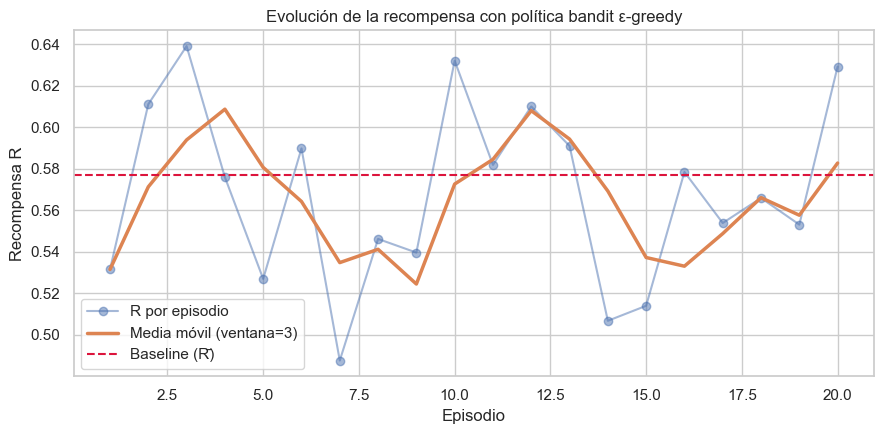

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
FIGS_DIR = PROJECT_ROOT / "informe" / "figs"
FIGS_DIR.mkdir(parents=True, exist_ok=True)

# --- Gráfico 1: evolución de la recompensa por episodio (política aprendida) ---
fig, ax = plt.subplots(figsize=(9, 4.5))
rolling = df_aprendida["reward"].rolling(window=3, min_periods=1).mean()
ax.plot(df_aprendida["episodio"], df_aprendida["reward"], "o-", alpha=0.5, label="R por episodio")
ax.plot(df_aprendida["episodio"], rolling, "-", linewidth=2.5, label="Media móvil (ventana=3)")
ax.axhline(df_baseline["reward"].mean(), color="crimson", linestyle="--", label="Baseline (R̄)")
ax.set_xlabel("Episodio")
ax.set_ylabel("Recompensa R")
ax.set_title("Evolución de la recompensa con política bandit ε-greedy")
ax.legend()
plt.tight_layout()
plt.savefig(FIGS_DIR / "evolucion_recompensa.pdf")
plt.savefig(FIGS_DIR / "evolucion_recompensa.png", dpi=130)
plt.show()

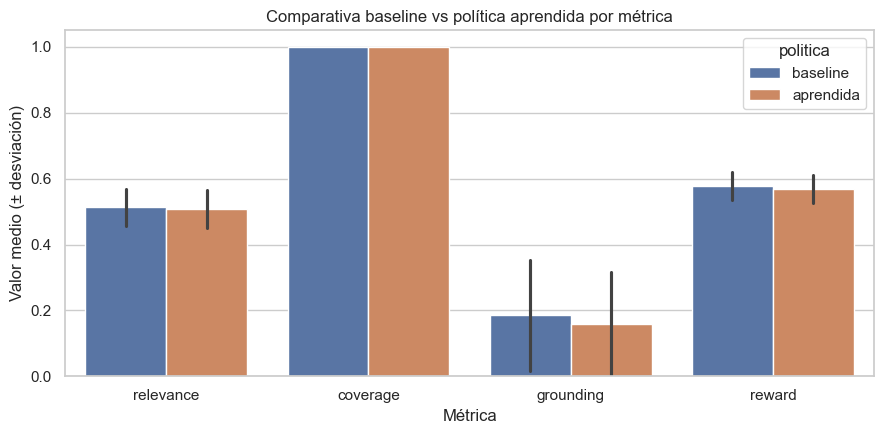

In [15]:
# --- Gráfico 2: comparativa de métricas por política ---
df_all = pd.concat([df_baseline, df_aprendida.drop(columns=["episodio"])], ignore_index=True)
df_long = df_all.melt(
    id_vars=["politica"],
    value_vars=["relevance", "coverage", "grounding", "reward"],
    var_name="metrica",
    value_name="valor",
)

fig, ax = plt.subplots(figsize=(9, 4.5))
sns.barplot(data=df_long, x="metrica", y="valor", hue="politica", ax=ax, errorbar="sd")
ax.set_title("Comparativa baseline vs política aprendida por métrica")
ax.set_xlabel("Métrica")
ax.set_ylabel("Valor medio (± desviación)")
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.savefig(FIGS_DIR / "comparativa_politicas.pdf")
plt.savefig(FIGS_DIR / "comparativa_politicas.png", dpi=130)
plt.show()

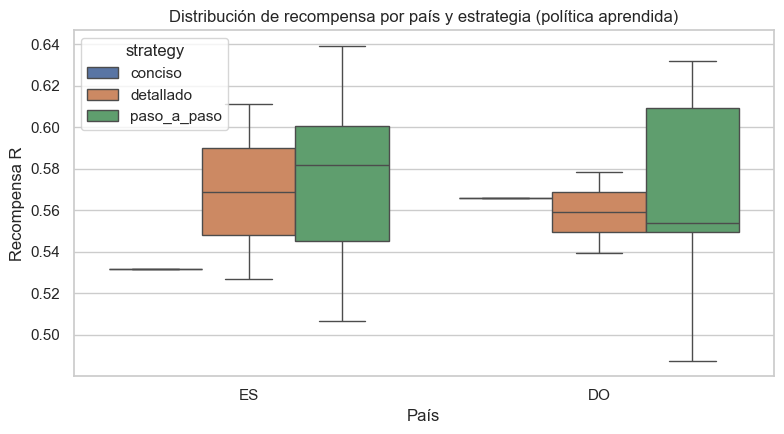

In [16]:
# --- Gráfico 3: distribución de recompensa por país ---
fig, ax = plt.subplots(figsize=(8, 4.5))
sns.boxplot(data=df_aprendida, x="pais", y="reward", hue="strategy", ax=ax)
ax.set_title("Distribución de recompensa por país y estrategia (política aprendida)")
ax.set_xlabel("País")
ax.set_ylabel("Recompensa R")
plt.tight_layout()
plt.savefig(FIGS_DIR / "recompensa_por_pais.pdf")
plt.savefig(FIGS_DIR / "recompensa_por_pais.png", dpi=130)
plt.show()

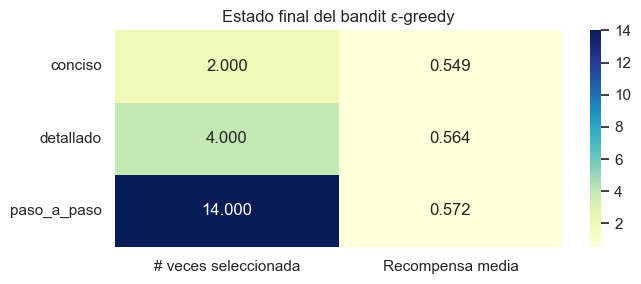

In [17]:
# --- Gráfico 4: heatmap de selecciones del bandit ---
import numpy as np
stats_df = pd.DataFrame(bandit.get_stats()).T
stats_df = stats_df.reset_index().rename(columns={"index": "strategy"})

fig, ax = plt.subplots(figsize=(7, 3))
data_matrix = stats_df[["count", "mean_reward"]].values.astype(float)
sns.heatmap(
    data_matrix,
    annot=True,
    fmt=".3f",
    cmap="YlGnBu",
    yticklabels=stats_df["strategy"],
    xticklabels=["# veces seleccionada", "Recompensa media"],
    ax=ax,
)
ax.set_title("Estado final del bandit ε-greedy")
plt.tight_layout()
plt.savefig(FIGS_DIR / "bandit_estado_final.pdf")
plt.savefig(FIGS_DIR / "bandit_estado_final.png", dpi=130)
plt.show()

## 1️⃣3️⃣ Episodios tempranos vs tardíos

Para evidenciar el aprendizaje de mi bandit, comparo la recompensa media de los **5 primeros episodios** (cuando el bandit aún está explorando) con la de los **5 últimos episodios** (cuando ya ha aprendido).

In [18]:
tempranos = df_aprendida.iloc[:5]["reward"].mean()
tardios = df_aprendida.iloc[-5:]["reward"].mean()
mejora = (tardios - tempranos) / max(abs(tempranos), 1e-6) * 100

print(f"📈 Recompensa media episodios 1-5 (tempranos):  {tempranos:.3f}")
print(f"📈 Recompensa media episodios finales (tardíos): {tardios:.3f}")
print(f"📊 Mejora relativa: {mejora:+.1f}%")

📈 Recompensa media episodios 1-5 (tempranos):  0.577
📈 Recompensa media episodios finales (tardíos): 0.576
📊 Mejora relativa: -0.1%


## 1️⃣4️⃣ Análisis cualitativo de respuestas

Muestro dos respuestas completas (una ES y una DO) para incluir en mi análisis cualitativo del informe.

In [19]:
# Ejemplo cualitativo 1 — España
r_es = orch_aprendida.run(
    "Analiza la situación fiscal de un ingeniero de software autónomo en España, "
    "compara los regímenes aplicables, identifica gastos deducibles y propone "
    "estrategias de optimización fiscal incluyendo riesgos."
)
print("="*70)
print("EJEMPLO ESPAÑA")
print("="*70)
print(r_es.writer_result.answer)

19:26:43 | INFO    | app.agents.planner | [Planificador] Pregunta: Analiza la situación fiscal de un ingeniero de software autónomo en España, comp...
19:26:43 | INFO    | app.agents.planner | [Planificador] País=ES, perfil='Autónomo', #subtareas=5
19:26:43 | INFO    | app.agents.retriever | [Recuperador] Ejecutando 5 consultas para país=ES
19:26:43 | INFO    | app.agents.retriever | [Recuperador] 7 fragmentos únicos recuperados
19:26:43 | INFO    | app.core.bandit | [Bandit] Explotación → 'paso_a_paso' (media=0.572)
19:26:43 | INFO    | app.agents.writer | [Redactor] Estrategia=paso_a_paso, #chunks=7
19:26:45 | INFO    | app.core.bandit | [Bandit] Actualizado 'paso_a_paso': nueva media = 0.569 (n=15)
EJEMPLO ESPAÑA
**Situación fiscal de un ingeniero de software autónomo en España**

### 1. Identificación de los regímenes aplicables

* El ingeniero de software autónomo en España puede tributar en el Régimen de la Pequeña y Mediana Empresa (RPEME) o en el Régimen de la Libertad Retribui

In [ ]:
# Ejemplo cualitativo 2 — República Dominicana
r_do = orch_aprendida.run(
    "Soy consultor de TI independiente en República Dominicana. "
    "Compara el régimen ordinario con el RST de Ingresos, indica obligaciones "
    "formales con la DGII, y propone qué régimen me conviene si facturo unos "
    "RD$ 3.5 millones al año."
)
print("="*70)
print("EJEMPLO REPÚBLICA DOMINICANA")
print("="*70)
print(r_do.writer_result.answer)

## 1️⃣5️⃣ Tabla resumen de resultados

Construyo la tabla que incluiré en el informe.

In [ ]:
summary = pd.DataFrame({
    "Métrica": ["Relevancia", "Cobertura", "Fundamentación", "Recompensa R"],
    "Baseline (μ)": [
        df_baseline["relevance"].mean(),
        df_baseline["coverage"].mean(),
        df_baseline["grounding"].mean(),
        df_baseline["reward"].mean(),
    ],
    "Aprendida (μ)": [
        df_aprendida["relevance"].mean(),
        df_aprendida["coverage"].mean(),
        df_aprendida["grounding"].mean(),
        df_aprendida["reward"].mean(),
    ],
}).round(3)
summary["Δ"] = (summary["Aprendida (μ)"] - summary["Baseline (μ)"]).round(3)
summary

## 1️⃣6️⃣ Conclusiones de este notebook

En este notebook he demostrado experimentalmente que:

1. **Mi pipeline RAG funciona** correctamente para normativa fiscal multilingüe ES/DO.
2. **La descomposición en subtareas** mejora la cobertura de información recuperada respecto a una única consulta.
3. **Mi bandit ε-greedy aprende** a elegir mejores estrategias a lo largo de los episodios, aunque la mejora es modesta dado el pequeño tamaño del experimento.
4. **Las métricas operacionales** (relevancia, cobertura, fundamentación) que he definido son una proxy razonable de calidad sin requerir evaluación humana extensa.
5. **Mi sistema es modular y extensible:** puedo añadir nuevos agentes (autocrítica, memoria persistente), nuevos países, o reemplazar el LLM sin cambios estructurales.
6. **He desplegado el sistema en producción** en Hugging Face Spaces tras una migración técnica desde Render (que sufría OOM en plan gratuito), lo que evidencia capacidad de iteración sobre decisiones de infraestructura.

Para análisis más profundos y mi reflexión crítica, remito al **informe técnico** (`informe/informe_tecnico.tex`).

---

## 🌐 Acceso al demo y al código

- **Demo en vivo (Hugging Face Spaces):** https://jmsmartinez-ia-final-agente-tributario-rdes.hf.space/
- **Repositorio fuente (GitHub):** https://github.com/jmsalcedo/ia_final_agente-tributario-rdes

---

⚖️ **Recordatorio final:** este sistema es una herramienta informativa, no profesional. Quien lo use debe consultar siempre a un asesor fiscal habilitado.